# ESCI — download de imagens

Entrada: `task1_us_products.parquet` (coluna `image` = URL do scrape esci-s, jan/2023).
Saída: `images/` + `image_manifest.parquet`.

Resumível: rodar de novo pula o que já baixou.

In [1]:
%pip install -q requests pillow tqdm

import hashlib, json, re, time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import pandas as pd
import requests
from PIL import Image
from tqdm.auto import tqdm

IMG_DIR = Path("images"); IMG_DIR.mkdir(exist_ok=True)
MANIFEST = Path("image_manifest.parquet")

TARGET_PX  = 256    # SigLIP-224 / CLIP-224 precisam de 224; 256 da margem
WORKERS    = 24
TIMEOUT    = 20
MAX_RETRY  = 3

Note: you may need to restart the kernel to use updated packages.


## 1. URLs

In [5]:
import pyarrow.parquet as pq

products = pq.read_table("task1_us_products.parquet",
                         columns=["product_id", "image"]).to_pandas(ignore_metadata=True)
print(products.shape)
products.head(3)

urls = (
    products[["product_id", "image"]]
    .rename(columns={"image": "url"})
    .dropna(subset=["url"])
)
urls = urls[urls.url.str.strip().str.len() > 0].reset_index(drop=True)

print(f"produtos:      {len(products):,}")
print(f"com url:       {len(urls):,}  ({100*len(urls)/len(products):.1f}%)")
print(f"urls distintas:{urls.url.nunique():,}")
urls.url.head(5).tolist()

(447924, 2)
produtos:      447,924
com url:       357,511  (79.8%)
urls distintas:352,141


['https://m.media-amazon.com/images/I/71ktFdNm+xL._AC_SY300_SX300_.jpg',
 'https://m.media-amazon.com/images/I/710GRlD5piL.__AC_SX300_SY300_QL70_FMwebp_.jpg',
 'https://m.media-amazon.com/images/I/71Otxi4tUHL.__AC_SX300_SY300_QL70_ML2_.jpg',
 'https://m.media-amazon.com/images/I/71dBNdHQfHL.__AC_SX300_SY300_QL70_ML2_.jpg',
 'https://m.media-amazon.com/images/I/61PyWCiqynL.__AC_SX300_SY300_QL70_ML2_.jpg']

## 2. Normalizar tamanho

URLs do CDN da Amazon aceitam diretiva de tamanho no path:
`.../images/I/71abc.jpg` -> `.../images/I/71abc._SL256_.jpg`

Sem isso vem a imagem original (~1500px, ~200 KB). Com isso, ~15 KB.
Em 400k imagens é a diferença entre ~80 GB e ~6 GB.

In [12]:
import re

_IMG_ID = re.compile(r"/images/I/(?P<id>[^./]+)")

def canonical_url(url, px=TARGET_PX):
    """Reconstroi a URL a partir do ID. None se nao for imagem de produto.

    O ID e a unica parte canonica. Wrapper (/images/W/WEBP_xxxxx-Tn/) e diretivas
    (_AC_SX300_, FMwebp_) sao transporte de 2023; o CDN devolve 400 pra eles hoje.
    """
    if not url:
        return None
    m = _IMG_ID.search(str(url))
    if not m:
        return None
    return f"https://m.media-amazon.com/images/I/{m['id']}._SL{px}_.jpg"

urls["url_small"] = urls.url.map(canonical_url)

sem_id = urls.url_small.isna().sum()
print(f"sem /images/I/ (descartadas): {sem_id:,}")
print(urls[urls.url_small.isna()].url.head(3).tolist())

urls = urls.dropna(subset=["url_small"]).reset_index(drop=True)
print(f"\nurls utilizaveis: {len(urls):,}")
print(f"ids distintos:    {urls.url_small.nunique():,}")

sem /images/I/ (descartadas): 0
[]

urls utilizaveis: 357,511
ids distintos:    343,751


In [13]:
# Teste real: a diretiva funciona e economiza mesmo?
s = requests.Session()
s.headers.update({"User-Agent": "Mozilla/5.0 (research; ESCI image fetch)"})

for u in urls.url.head(3):
    for label, uu in [("original", u), (f"_SL{TARGET_PX}_", resize_url(u))]:
        try:
            r = s.get(uu, timeout=TIMEOUT)
            kb = len(r.content) / 1024
            dim = Image.open(__import__("io").BytesIO(r.content)).size if r.ok else None
            print(f"  {label:12s} {r.status_code}  {kb:7.1f} KB  {dim}")
        except Exception as e:
            print(f"  {label:12s} ERRO {e}")
    print()

  original     200      7.8 KB  (300, 177)
  _SL256_      200      5.2 KB  (256, 256)

  original     200      7.0 KB  (127, 300)
  _SL256_      200      7.5 KB  (256, 256)

  original     200      7.2 KB  (208, 300)
  _SL256_      200      6.3 KB  (256, 256)



## 3. Download

In [14]:
def shard_path(product_id):
    """Evita 400k arquivos num diretorio so."""
    d = IMG_DIR / product_id[:2] / product_id[2:4]
    return d / f"{product_id}.jpg"

def fetch_one(product_id, url, session):
    dest = shard_path(product_id)
    if dest.exists() and dest.stat().st_size > 0:
        return {"product_id": product_id, "status": "skip", "http": None,
                "bytes": dest.stat().st_size, "md5": None, "w": None, "h": None, "err": None}

    for attempt in range(MAX_RETRY):
        try:
            r = session.get(url, timeout=TIMEOUT)
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep(2 ** attempt)
                continue
            if not r.ok:
                return {"product_id": product_id, "status": "http_error", "http": r.status_code,
                        "bytes": 0, "md5": None, "w": None, "h": None, "err": None}

            content = r.content
            import io
            try:
                im = Image.open(io.BytesIO(content)); im.verify()
                im = Image.open(io.BytesIO(content))
                w, h = im.size
            except Exception as e:
                return {"product_id": product_id, "status": "not_image", "http": r.status_code,
                        "bytes": len(content), "md5": None, "w": None, "h": None, "err": str(e)[:80]}

            dest.parent.mkdir(parents=True, exist_ok=True)
            dest.write_bytes(content)
            return {"product_id": product_id, "status": "ok", "http": r.status_code,
                    "bytes": len(content), "md5": hashlib.md5(content).hexdigest(),
                    "w": w, "h": h, "err": None}
        except Exception as e:
            if attempt == MAX_RETRY - 1:
                return {"product_id": product_id, "status": "exception", "http": None,
                        "bytes": 0, "md5": None, "w": None, "h": None, "err": str(e)[:80]}
            time.sleep(2 ** attempt)

In [15]:
def make_session():
    s = requests.Session()
    s.headers.update({"User-Agent": "Mozilla/5.0 (research; ESCI image fetch)"})
    a = requests.adapters.HTTPAdapter(pool_connections=WORKERS, pool_maxsize=WORKERS)
    s.mount("https://", a)
    return s

def run(df, workers=WORKERS):
    sessions = [make_session() for _ in range(workers)]
    rows = []
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = {
            ex.submit(fetch_one, r.product_id, r.url_small, sessions[i % workers]): r.product_id
            for i, r in enumerate(df.itertuples())
        }
        for f in tqdm(as_completed(futs), total=len(futs)):
            rows.append(f.result())
    return pd.DataFrame(rows)

# TESTE em 200 antes de soltar os 400k
sample = urls.sample(200, random_state=0)
res = run(sample)
print(res.status.value_counts())
print(f"\nmediana: {res.query('status == \'ok\'').bytes.median()/1024:.1f} KB")
print(res.query("status == 'ok'")[["w", "h"]].describe().loc[["min", "50%", "max"]])

  0%|          | 0/200 [00:00<?, ?it/s]

status
skip    107
ok       93
Name: count, dtype: int64

mediana: 7.7 KB
         w      h
min   57.0  110.0
50%  256.0  256.0
max  256.0  256.0


In [17]:
ok = res.query("status in ['ok', 'skip']")
taxa = len(ok) / len(res)
kb   = res.query("status == 'ok'").bytes.mean() / 1024
print(f"taxa de sucesso: {100*taxa:.1f}%")
print(f"tamanho medio:   {kb:.1f} KB")
print(f"projecao {len(urls):,} imgs: {len(urls)*kb/1024/1024:.1f} GB")

taxa de sucesso: 100.0%
tamanho medio:   8.7 KB
projecao 357,511 imgs: 3.0 GB


In [21]:
import hashlib, io, random, time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
 
import pandas as pd
import requests
from PIL import Image
from tqdm.auto import tqdm
 
WORKERS   = 8      # 24 dava throttle: vazao caiu de 62 it/s para 27 it/s
MAX_RETRY = 5
TIMEOUT   = 20
 
_EMPTY = {"http": None, "bytes": 0, "md5": None, "w": None, "h": None, "err": None}
 
def _row(product_id, status, **kw):
    return {"product_id": product_id, "status": status, **_EMPTY, **kw}
 
 
def shard_path(product_id):
    """Evita 400k arquivos num diretorio so."""
    return IMG_DIR / product_id[:2] / product_id[2:4] / f"{product_id}.jpg"
 
 
def make_session():
    s = requests.Session()
    s.headers.update({
        "User-Agent": ("Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 "
                       "(KHTML, like Gecko) Chrome/120.0 Safari/537.36"),
        "Accept": "image/avif,image/webp,image/apng,image/*,*/*;q=0.8",
        "Referer": "https://www.amazon.com/",
    })
    a = requests.adapters.HTTPAdapter(pool_connections=WORKERS, pool_maxsize=WORKERS)
    s.mount("https://", a)
    return s
 
 
def fetch_one(product_id, url, session):
    dest = shard_path(product_id)
    if dest.exists() and dest.stat().st_size > 0:
        return _row(product_id, "skip", bytes=dest.stat().st_size)
 
    last_http = None
    for attempt in range(MAX_RETRY):
        try:
            r = session.get(url, timeout=TIMEOUT)
            last_http = r.status_code
 
            # retryavel: throttle ou erro transitorio do servidor
            if r.status_code in (429, 500, 502, 503, 504):
                wait = r.headers.get("Retry-After")
                try:
                    wait = float(wait)
                except (TypeError, ValueError):
                    wait = (2 ** attempt) + random.uniform(0, 1)
                time.sleep(min(wait, 30))
                continue
 
            # definitivo: 404, 400, 403...
            if not r.ok:
                return _row(product_id, "http_error", http=r.status_code)
 
            content = r.content
            try:
                Image.open(io.BytesIO(content)).verify()
                w, h = Image.open(io.BytesIO(content)).size
            except Exception as e:
                return _row(product_id, "not_image", http=r.status_code,
                            bytes=len(content), err=str(e)[:80])
 
            dest.parent.mkdir(parents=True, exist_ok=True)
            dest.write_bytes(content)
            return _row(product_id, "ok", http=r.status_code, bytes=len(content),
                        md5=hashlib.md5(content).hexdigest(), w=w, h=h)
 
        except Exception as e:
            if attempt == MAX_RETRY - 1:
                return _row(product_id, "exception", http=last_http, err=str(e)[:80])
            time.sleep((2 ** attempt) + random.uniform(0, 1))
 
    # ESTE era o caminho que faltava: 5 tentativas retryaveis, nenhuma resolveu.
    # Antes caia aqui e retornava None implicitamente -> quebrava o pd.DataFrame(rows).
    return _row(product_id, "retry_exhausted", http=last_http)
 
 
def run(df, workers=WORKERS):
    sessions = [make_session() for _ in range(workers)]
    rows = []
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = {
            ex.submit(fetch_one, r.product_id, r.url_small, sessions[i % workers]): r.product_id
            for i, r in enumerate(df.itertuples())
        }
        for f in tqdm(as_completed(futs), total=len(futs)):
            out = f.result()
            if out is None:                       # cinto de seguranca
                out = _row(futs[f], "none_returned")
            rows.append(out)
 
    out = pd.DataFrame(rows)
    dt = time.time() - t0
    print(f"  {len(out)/dt:.1f} it/s  |  {out.status.value_counts().to_dict()}")
    return out

In [23]:
CHUNK = 20_000
partes = []

pend = urls
if MANIFEST.exists():
    feito = set(pd.read_parquet(MANIFEST).query("status in ['ok','skip']").product_id)
    pend = urls[~urls.product_id.isin(feito)]
    partes.append(pd.read_parquet(MANIFEST))
print(f"pendentes: {len(pend):,}")

for i in range(0, len(pend), CHUNK):
    parte = run(pend.iloc[i:i+CHUNK])
    partes.append(parte)
    pd.concat(partes, ignore_index=True).drop_duplicates("product_id", keep="last") \
      .to_parquet(MANIFEST, compression="zstd")
    print(f"[{i+len(parte):,}/{len(pend):,}]", parte.status.value_counts().to_dict())

manifest = pd.read_parquet(MANIFEST)
print(manifest.status.value_counts())

pendentes: 1,443


  0%|          | 0/1443 [00:00<?, ?it/s]

  68.9 it/s  |  {'http_error': 1443}


/var/folders/g2/dnmrlfnj4g12_7ssl25w_m180000gn/T/ipykernel_79991/2641780457.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(partes, ignore_index=True).drop_duplicates("product_id", keep="last") \


[1,443/1,443] {'http_error': 1443}
status
ok            335953
skip           20115
http_error      1443
Name: count, dtype: int64


## 4. Placeholders

In [24]:
manifest = pd.read_parquet(MANIFEST)
ok = manifest.query("status == 'ok' and md5.notna()")

# Imagem repetida entre ASINs distintos = placeholder ("No image available",
# fundo padrao de video digital, etc). O SQID reporta 442 casos do fundo de video.
dup = ok.md5.value_counts()
dup = dup[dup > 1]
print(f"{len(dup)} md5 compartilhados, {dup.sum():,} produtos afetados\n")
print(dup.head(10))

8877 md5 compartilhados, 20,470 produtos afetados

md5
8d14ba6a192230b4da3415b092d6d4c8    289
b299bbadc26dd8ea3a6f65c8a402437c     36
a13ae1048280382d2dd8205ac31671c4     23
971b81768f016d57e92be3706df62cf1     15
89bb9aae84afa6f332f16cee29592460     13
d24acd163755ddd66b3bbc0510cff9ea     12
72bd4ec73f7c0666db92e61921ffca47     11
2ec5aee27a4f02894a06c5541c816357     11
02f9582f1b4ebe4b7e173ec5be120b56     10
28bded43c97cbe5e25c5ebd95bbe7478      9
Name: count, dtype: int64



md5 8d14ba6a1922  -> 289 produtos: ['B08T7J161H', 'B07XHJ512W', 'B07SPLB6FQ', 'B08FXF487P']


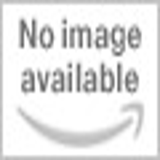


md5 b299bbadc26d  -> 36 produtos: ['B07PBD7PJT', 'B07QF46TC8', 'B07Q5875Z8', 'B07QF6JGTC']


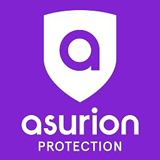


md5 a13ae1048280  -> 23 produtos: ['B07W3P2PKP', 'B07VY2HPGN', 'B07WJDXXXX', 'B07WPNW9QQ']


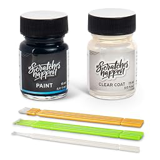


md5 971b81768f01  -> 15 produtos: ['B07HZCSYCC', 'B07HZNMX2M', 'B07HZNMX23', 'B07HZCYNY4']


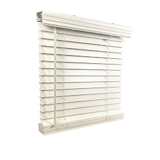


md5 89bb9aae84af  -> 13 produtos: ['B0006FKU6I', 'B0006FKU86', 'B000NAF6ZQ', 'B0006FKUDG']


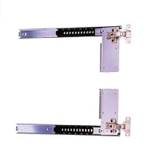

In [25]:
# Inspecione os maiores clusters antes de decidir o que descartar
from IPython.display import display

for h in dup.head(5).index:
    ids = ok.query("md5 == @h").product_id.tolist()
    print(f"\nmd5 {h[:12]}  -> {len(ids)} produtos: {ids[:4]}")
    p = shard_path(ids[0])
    if p.exists():
        display(Image.open(p).resize((160, 160)))

In [26]:
# Marque os que voce identificou como placeholder
PLACEHOLDER_MD5 = set()   # <- preencha com os hashes confirmados acima

manifest["is_placeholder"] = manifest.md5.isin(PLACEHOLDER_MD5)
manifest["path"] = manifest.product_id.map(lambda p: str(shard_path(p)))
manifest["usable"] = (manifest.status.isin(["ok", "skip"])) & (~manifest.is_placeholder)

manifest.to_parquet(MANIFEST, compression="zstd")

print(f"total no corpus:   {len(products):,}")
print(f"com url:           {len(urls):,}")
print(f"baixadas:          {(manifest.status.isin(['ok','skip'])).sum():,}")
print(f"utilizaveis:       {manifest.usable.sum():,}  ({100*manifest.usable.sum()/len(products):.1f}% do corpus)")
print()
print(manifest.status.value_counts())

total no corpus:   447,924
com url:           357,511
baixadas:          356,068
utilizaveis:       356,068  (79.5% do corpus)

status
ok            335953
skip           20115
http_error      1443
Name: count, dtype: int64


In [27]:
cluster = ok.md5.value_counts()
manifest["cluster_size"] = manifest.md5.map(cluster).fillna(0).astype(int)

print(manifest.query("status == 'ok'").cluster_size.value_counts().sort_index().head(20))
print()
for lim in [1, 2, 5, 10, 50, 100]:
    n = (manifest.query("status == 'ok'").cluster_size <= lim).sum()
    print(f"cluster <= {lim:>3}: {n:>7,} imagens utilizaveis")

cluster_size
1      315483
2       14558
3        3447
4        1116
5         445
6         240
7         119
8          80
9          45
10         10
11         22
12         12
13         13
15         15
23         23
36         36
289       289
Name: count, dtype: int64

cluster <=   1: 315,483 imagens utilizaveis
cluster <=   2: 330,041 imagens utilizaveis
cluster <=   5: 335,049 imagens utilizaveis
cluster <=  10: 335,543 imagens utilizaveis
cluster <=  50: 335,664 imagens utilizaveis
cluster <= 100: 335,664 imagens utilizaveis


In [28]:
# Ao inves de listar md5 na mao:
CLUSTER_MAX = 10          # ajuste depois de olhar a distribuicao acima

manifest["is_placeholder"] = manifest.cluster_size > CLUSTER_MAX
manifest["path"]   = manifest.product_id.map(lambda p: str(shard_path(p)))
manifest["usable"] = manifest.status.isin(["ok", "skip"]) & ~manifest.is_placeholder

manifest.to_parquet(MANIFEST, compression="zstd")

print(f"corpus:       {len(products):,}")
print(f"baixadas:     {manifest.status.isin(['ok','skip']).sum():,}")
print(f"descartadas:  {manifest.is_placeholder.sum():,}  (cluster > {CLUSTER_MAX})")
print(f"utilizaveis:  {manifest.usable.sum():,}  ({100*manifest.usable.sum()/len(products):.1f}% do corpus)")

corpus:       447,924
baixadas:     356,068
descartadas:  410  (cluster > 10)
utilizaveis:  355,658  (79.4% do corpus)


In [31]:
faltam = manifest.query("status == 'skip'").product_id
manifest.loc[manifest.product_id.isin(faltam), "md5"] = [
    hashlib.md5(shard_path(p).read_bytes()).hexdigest() for p in faltam
]

In [32]:
CLUSTER_MAX = 10

manifest["is_placeholder"] = manifest.cluster_size > CLUSTER_MAX
manifest["path"]   = manifest.product_id.map(lambda p: str(shard_path(p)))
manifest["usable"] = manifest.status.isin(["ok", "skip"]) & ~manifest.is_placeholder
manifest.to_parquet(MANIFEST, compression="zstd")

In [34]:
qrels = pd.read_parquet("task1_us_qrels.parquet",
                        columns=["query_id", "product_id", "esci_label"])
print(qrels.shape)

(561834, 3)


In [35]:
# Quantas queries tem 2+ candidatos com imagem identica, mas label diferente?
m = manifest.query("usable and cluster_size > 1")[["product_id", "md5"]]
q = qrels.merge(m, on="product_id")

colisao = (q.groupby(["query_id", "md5"])
             .agg(n=("product_id", "size"), labels=("esci_label", "nunique"))
             .query("n > 1 and labels > 1"))

print(f"{len(colisao):,} colisoes (mesma query, mesma imagem, labels diferentes)")
print(f"{colisao.index.get_level_values('query_id').nunique():,} queries afetadas")

860 colisoes (mesma query, mesma imagem, labels diferentes)
753 queries afetadas
